Extracted 5 distinct coins.


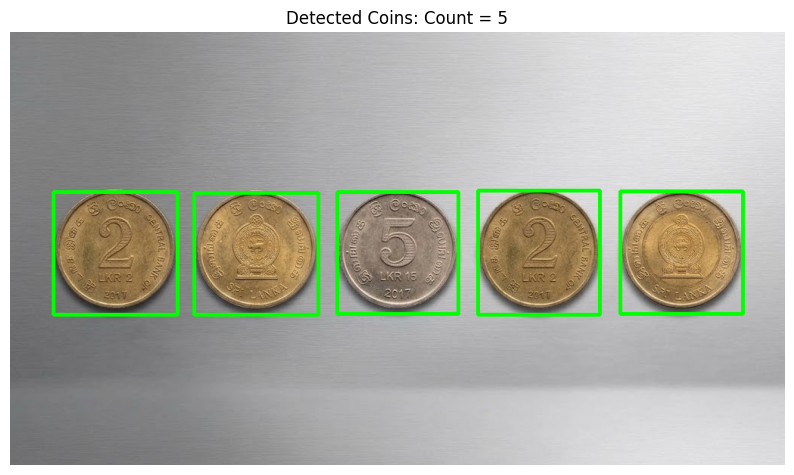

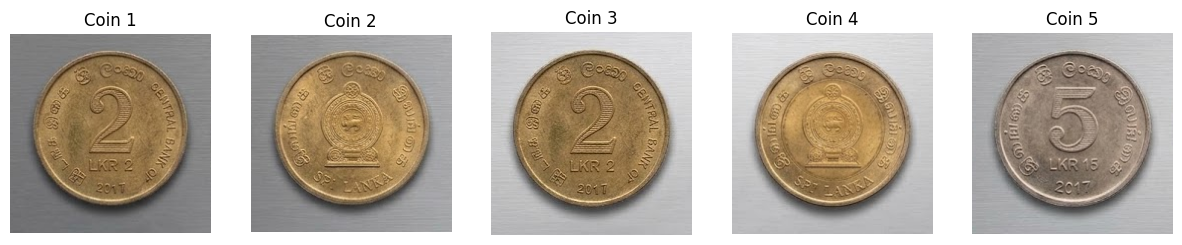

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the original image
image_path = 'coins.jpg'
image = cv2.imread(image_path)
output_image = image.copy()

# here we convert image from color Blue, green, red to grey style
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (15, 15), 0)

# here we convert gray style image to binary image
thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 4)

# Makes a small, round tool (15x15 pixels) to act like a paintbrush.- code one
# code 2 - Uses that round brush on your image to smooth it out—filling in tiny holes and gluing broken pieces of the coins back together.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# trace the outlines of all the solid shapes in your image.
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# This code figures out how to draw a tight rectangular box around each valid coin. [x, y, w, h]
boxes = []
for c in contours:
    area = cv2.contourArea(c)
    if area > 150:
        x, y, w, h = cv2.boundingRect(c)
        # Skip boxes that span the entire image width/height (image borders)
        if w < image.shape[1] * 0.9 and h < image.shape[0] * 0.9:
            boxes.append([x, y, w, h])

# Overlap Filtering to merge duplicate detections on the same coin
def get_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

unique_boxes = []
# Sort boxes by size (area) descending to prioritize complete detections
boxes = sorted(boxes, key=lambda b: b[2] * b[3], reverse=True)

for box in boxes:
    overlap = False
    for u_box in unique_boxes:
        if get_iou(box, u_box) > 0.2:  # Overlap threshold
            overlap = True
            break
    if not overlap:
        unique_boxes.append(box)

# Keep exactly the top 5 largest unique bounding boxes
unique_boxes = sorted(unique_boxes, key=lambda b: b[2] * b[3], reverse=True)[:5]

# Extract and Crop Each Coin
extracted_coins = []

for i, (x, y, w, h) in enumerate(unique_boxes):
    # to Draw a green rectangle on our output image
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 4)

    # Crop the coin out of the ORIGINAL image with padding
    padding = 20
    y_start = max(0, y - padding)
    y_end = min(image.shape[0], y + h + padding)
    x_start = max(0, x - padding)
    x_end = min(image.shape[1], x + w + padding)

    coin_roi = image[y_start:y_end, x_start:x_end]
    extracted_coins.append(coin_roi)

print(f"Extracted {len(extracted_coins)} distinct coins.")

# Display the Results
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Coins: Count = {len(extracted_coins)}')
plt.axis('off')
plt.show()

# Display the cropped individual coins
if extracted_coins:
    fig, axes = plt.subplots(1, len(extracted_coins), figsize=(15, 5))
    if len(extracted_coins) == 1:
        axes = [axes]

    for i, coin in enumerate(extracted_coins):
        axes[i].imshow(cv2.cvtColor(coin, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Coin {i+1}")
        axes[i].set_axis_off()
    plt.show()
else:
    print("No coins extracted to display.")

In [ ]:
# Output the final count of the detected coins
total_coins = len(extracted_coins)
print(f"Total number of coins in the image: {total_coins}")

Total number of coins in the image: 5
